In [1]:
!pip install -q earthengine-api geemap

In [2]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import ee

ee.Authenticate(auth_mode="colab")

In [4]:
ee.Initialize(project="heatsense")

print("Google Earth Engine initialized successfully!")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Google Earth Engine initialized successfully!


In [5]:
karnataka = (
    ee.FeatureCollection("FAO/GAUL/2015/level1")
    .filter(ee.Filter.eq("ADM1_NAME", "Karnataka"))
)

print("Karnataka boundary loaded.")

Karnataka boundary loaded.


/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


In [6]:
landsat8 = ee.ImageCollection(
    "LANDSAT/LC08/C02/T1_L2"
)

In [7]:
landsat9 = ee.ImageCollection(
    "LANDSAT/LC09/C02/T1_L2"
)

In [8]:
era5 = ee.ImageCollection(
    "ECMWF/ERA5_LAND/DAILY_AGGR"
)

In [9]:
worldcover = ee.ImageCollection(
    "ESA/WorldCover/v200/2021"
)

In [10]:
print("Datasets loaded.")

Datasets loaded.


In [11]:
START_DATE = "2013-01-01"
END_DATE = "2026-09-23"

print("Start:", START_DATE)
print("End:", END_DATE)

Start: 2013-01-01
End: 2026-09-23


In [12]:
def mask_landsat(image):

    qa = image.select("QA_PIXEL")

    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_shadow = qa.bitwiseAnd(1 << 4).eq(0)

    return (
        image
        .updateMask(cloud)
        .updateMask(cloud_shadow)
    )

In [13]:
def process_landsat(image):

    image = mask_landsat(image)

    # Surface temperature
    lst = (
        image.select("ST_B10")
        .multiply(0.00341802)
        .add(149.0)
        .subtract(273.15)
        .rename("LST")
    )

    # NDVI
    ndvi = (
        image
        .normalizedDifference(["SR_B5", "SR_B4"])
        .rename("NDVI")
    )

    # NDBI
    ndbi = (
        image
        .normalizedDifference(["SR_B6", "SR_B5"])
        .rename("NDBI")
    )

    return image.addBands([
        lst,
        ndvi,
        ndbi
    ])

In [14]:
l8 = (
    landsat8
    .filterBounds(karnataka)
    .filterDate(START_DATE, END_DATE)
    .map(process_landsat)
)

l9 = (
    landsat9
    .filterBounds(karnataka)
    .filterDate(START_DATE, END_DATE)
    .map(process_landsat)
)

landsat = l8.merge(l9)

print("Number of Landsat images:")
print(landsat.size().getInfo())

Number of Landsat images:
7315


In [15]:
landsat_composite = (
    landsat
    .select(["LST", "NDVI", "NDBI"])
    .median()
    .clip(karnataka)
)

print("Landsat composite created.")

Landsat composite created.


In [16]:
era = (
    era5
    .filterBounds(karnataka)
    .filterDate(START_DATE, END_DATE)
)

print("ERA5-Land images:")
print(era.size().getInfo())

ERA5-Land images:
5008


In [17]:
def process_era5(image):

    # Air temperature
    air_temp = (
        image
        .select("temperature_2m")
        .subtract(273.15)
        .rename("Air_Temperature")
    )

    # Dew point temperature
    dew_temp = (
        image
        .select("dewpoint_temperature_2m")
        .subtract(273.15)
    )

    # Wind components
    u = image.select("u_component_of_wind_10m")
    v = image.select("v_component_of_wind_10m")

    # Wind speed
    wind = (
        u.pow(2)
        .add(v.pow(2))
        .sqrt()
        .rename("Wind_Speed")
    )

    # Relative humidity using Magnus formula
    rh = (
        dew_temp.expression(
            """
            100 * exp(
                (17.625 * Td) / (243.04 + Td)
                -
                (17.625 * T) / (243.04 + T)
            )
            """,
            {
                "Td": dew_temp,
                "T": air_temp
            }
        )
        .clamp(0, 100)
        .rename("Relative_Humidity")
    )

    return image.addBands([
        air_temp,
        rh,
        wind
    ])

In [18]:
era_processed = era.map(process_era5)

era_composite = (
    era_processed
    .select([
        "Air_Temperature",
        "Relative_Humidity",
        "Wind_Speed"
    ])
    .mean()
    .clip(karnataka)
)

print("ERA5 environmental variables calculated.")

ERA5 environmental variables calculated.


In [19]:
wc = (
    ee.ImageCollection(
        "ESA/WorldCover/v200/2021"
    )
    .first()
    .clip(karnataka)
)

print("WorldCover loaded.")

WorldCover loaded.


In [20]:
worldcover = (
    ee.ImageCollection(
        "ESA/WorldCover/v200/2021"
    )
    .first()
    .clip(karnataka)
)

lulc_heat = worldcover.remap(
    [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100],
    [0.1, 0.2, 0.3, 0.5, 1.0, 0.8, 0.4, 0.0, 0.2, 0.1, 0.3]
).rename("LULC_Heat")

print("LULC heat layer created successfully.")

LULC heat layer created successfully.


In [21]:
raw_lst = landsat_composite.select("LST")
raw_ndvi = landsat_composite.select("NDVI")
raw_ndbi = landsat_composite.select("NDBI")

raw_air = era_composite.select("Air_Temperature")
raw_rh = era_composite.select("Relative_Humidity")
raw_wind = era_composite.select("Wind_Speed")

stack = raw_lst.addBands([
    raw_ndvi,
    raw_ndbi,
    raw_air,
    raw_rh,
    raw_wind,
    lulc_heat
])

print("Seven HeatSense factors combined.")

Seven HeatSense factors combined.


In [22]:
print("raw_lst:", "raw_lst" in globals())
print("raw_ndvi:", "raw_ndvi" in globals())
print("raw_ndbi:", "raw_ndbi" in globals())
print("raw_air:", "raw_air" in globals())
print("raw_rh:", "raw_rh" in globals())
print("raw_wind:", "raw_wind" in globals())
print("lulc_heat:", "lulc_heat" in globals())

raw_lst: True
raw_ndvi: True
raw_ndbi: True
raw_air: True
raw_rh: True
raw_wind: True
lulc_heat: True


In [23]:
from google.colab import files

uploaded = files.upload()

Saving preprocessing.py to preprocessing.py


In [24]:
from pathlib import Path

file_path = Path("/content/preprocessing.py")

if file_path.exists():
    print("preprocessing.py found.")
else:
    print("preprocessing.py NOT found.")

preprocessing.py found.


In [25]:
with open(
    "/content/preprocessing.py",
    "r",
    encoding="utf-8"
) as f:

    preprocessing_code = f.read()

print(preprocessing_code[:15000])

"""
HeatSense Preprocessing Module.
Handles ingestion, cloud-masking, cropping, and aggregate statistics extraction
for satellite imagery (e.g., Landsat, MODIS, Sentinel) using the Google Earth Engine Python API.
"""

import os
import math

# Store Earth Engine initialization state globally
_EE_INITIALIZED = False
_EE_ERROR_MSG = "Not initialized"

def initialize_earth_engine(project_id=None):
    """
    Initializes and authenticates the Google Earth Engine (EE) client.
    Supports optional project ID from parameter or environment variable.
    """
    global _EE_INITIALIZED, _EE_ERROR_MSG
    try:
        import ee
        project = (
            project_id
            or os.environ.get('EE_PROJECT')
            or os.environ.get('EARTHENGINE_PROJECT')
            or os.environ.get('GOOGLE_CLOUD_PROJECT')
        )
        if project:
            ee.Initialize(project=project)
        else:
            ee.Initialize()
        _EE_INITIALIZED = True
        _EE_ERROR_MSG = ""
       

In [28]:
print(preprocessing_code[:5000])

"""
HeatSense Preprocessing Module.
Handles ingestion, cloud-masking, cropping, and aggregate statistics extraction
for satellite imagery (e.g., Landsat, MODIS, Sentinel) using the Google Earth Engine Python API.
"""

import os
import math

# Store Earth Engine initialization state globally
_EE_INITIALIZED = False
_EE_ERROR_MSG = "Not initialized"

def initialize_earth_engine(project_id=None):
    """
    Initializes and authenticates the Google Earth Engine (EE) client.
    Supports optional project ID from parameter or environment variable.
    """
    global _EE_INITIALIZED, _EE_ERROR_MSG
    try:
        import ee
        project = (
            project_id
            or os.environ.get('EE_PROJECT')
            or os.environ.get('EARTHENGINE_PROJECT')
            or os.environ.get('GOOGLE_CLOUD_PROJECT')
        )
        if project:
            ee.Initialize(project=project)
        else:
            ee.Initialize()
        _EE_INITIALIZED = True
        _EE_ERROR_MSG = ""
       

In [29]:
import re

functions = re.findall(
    r"^\s*def\s+([A-Za-z_][A-Za-z0-9_]*)",
    preprocessing_code,
    re.MULTILINE
)

print("Functions found:")
for f in functions:
    print("-", f)

Functions found:
- initialize_earth_engine
- get_gee_status
- get_karnataka_boundary
- mask_landsat_clouds
- apply_landsat_scaling
- get_live_weather
- process_landsat_data
- get_lulc_data
- get_era5_land_daily_climate
- normalize_gee_band
- get_lulc_heat_score
- calculate_composite_heat_index
- classify_heat_hotspots
- get_location_features
- _lat_lon_fallback
- get_annual_summer_composite
- calculate_lst_trend_slope
- calculate_epoch_difference
- get_district_historical_trend
- get_location_historical_trend


In [26]:
start = preprocessing_code.find(
    "def create_training_image"
)

if start == -1:
    print("create_training_image() was not found.")
else:
    print(
        preprocessing_code[
            start:start + 15000
        ]
    )

create_training_image() was not found.


In [27]:
def normalize_image(image, region, scale=5000):

    band_name = image.bandNames().get(0)

    stats = image.reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=region,
        scale=scale,
        maxPixels=1e8,
        bestEffort=True,
        tileScale=4
    )

    min_value = ee.Number(
        stats.get(
            ee.String(band_name).cat("_min")
        )
    )

    max_value = ee.Number(
        stats.get(
            ee.String(band_name).cat("_max")
        )
    )

    return (
        image
        .subtract(min_value)
        .divide(
            max_value.subtract(min_value)
        )
        .clamp(0, 1)
    )

print("Normalization function created.")

Normalization function created.


In [30]:
region = karnataka.geometry()

lst_n = (
    normalize_image(
        raw_lst,
        region
    )
    .rename("LST_n")
)

air_n = (
    normalize_image(
        raw_air,
        region
    )
    .rename("AirT_n")
)

ndbi_n = (
    normalize_image(
        raw_ndbi,
        region
    )
    .rename("NDBI_n")
)

rh_n = (
    normalize_image(
        raw_rh,
        region
    )
    .rename("RH_n")
)

ndvi_n = (
    normalize_image(
        raw_ndvi,
        region
    )
    .rename("NDVI_n")
)

wind_n = (
    normalize_image(
        raw_wind,
        region
    )
    .rename("Wind_n")
)

print("All normalized factors created.")

All normalized factors created.


In [31]:
print("lst_n:", "lst_n" in globals())
print("air_n:", "air_n" in globals())
print("ndbi_n:", "ndbi_n" in globals())
print("rh_n:", "rh_n" in globals())
print("ndvi_n:", "ndvi_n" in globals())
print("wind_n:", "wind_n" in globals())

lst_n: True
air_n: True
ndbi_n: True
rh_n: True
ndvi_n: True
wind_n: True


In [32]:
worldcover = (
    ee.Image(
        "ESA/WorldCover/v200/2021"
    )
    .clip(karnataka)
)

lulc_heat = worldcover.remap(
    [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100],
    [0.1, 0.2, 0.3, 0.5, 1.0, 0.8, 0.4, 0.0, 0.2, 0.1, 0.3]
).rename("LULC_Heat")

print("LULC heat created.")

LULC heat created.


In [33]:
chi = (
    lst_n.multiply(0.25)
    .add(air_n.multiply(0.20))
    .add(ndbi_n.multiply(0.15))
    .add(lulc_heat.multiply(0.15))
    .add(rh_n.multiply(0.10))
    .add(ndvi_n.multiply(-0.10))
    .add(wind_n.multiply(-0.05))
    .add(0.15)
    .rename("CHI")
)

print("CHI created successfully.")

CHI created successfully.


In [34]:
training_image = (
    lst_n
    .addBands(ndvi_n)
    .addBands(ndbi_n)
    .addBands(air_n)
    .addBands(rh_n)
    .addBands(wind_n)
    .addBands(lulc_heat)
    .addBands(chi)
)

print(
    training_image.bandNames().getInfo()
)

['LST_n', 'NDVI_n', 'NDBI_n', 'AirT_n', 'RH_n', 'Wind_n', 'LULC_Heat', 'CHI']


In [36]:
samples = training_image.sample(
    region=karnataka.geometry(),
    scale=1000,
    numPixels=500,
    seed=42,
    geometries=False,
    tileScale=8
)

print("Sample collection created.")

Sample collection created.


In [37]:
task_description = (
    "HeatSense_Training_Samples_Export"
)

task = ee.batch.Export.table.toDrive(
    collection=samples,
    description=task_description,
    folder="ee_exports",
    fileNamePrefix=task_description,
    fileFormat="CSV"
)

task.start()

print(
    f"Export task '{task_description}' started."
)

Export task 'HeatSense_Training_Samples_Export' started.


In [38]:
print(task.status())

{'state': 'RUNNING', 'description': 'HeatSense_Training_Samples_Export', 'priority': 100, 'creation_timestamp_ms': 1790313026946, 'update_timestamp_ms': 1790313052264, 'start_timestamp_ms': 1790313031957, 'task_type': 'EXPORT_FEATURES', 'attempt': 1, 'batch_eecu_usage_seconds': 23.695720672, 'id': 'GHU6VUMT37CF5WIBYNJI26IR', 'name': 'projects/heatsense/operations/GHU6VUMT37CF5WIBYNJI26IR'}


In [39]:
from google.colab import files

uploaded = files.upload()


Saving HeatSense_Training_Samples_Export.csv to HeatSense_Training_Samples_Export.csv


In [40]:
import pandas as pd

df = pd.read_csv("HeatSense_Training_Samples_Export.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (498, 10)

Columns:
['system:index', 'AirT_n', 'CHI', 'LST_n', 'LULC_Heat', 'NDBI_n', 'NDVI_n', 'RH_n', 'Wind_n', '.geo']


,system:index,AirT_n,CHI,LST_n,LULC_Heat,NDBI_n,NDVI_n,RH_n,Wind_n,.geo
0,0,0.626041,0.483613,0.546738,0.5,0.401429,0.633833,0.304473,0.611148,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,0.434056,0.517104,0.570068,0.5,0.695125,0.547170,0.452453,0.640432,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,0.328002,0.421039,0.408677,0.5,0.459099,0.668587,0.532355,0.539446,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,0.900456,0.689349,0.895247,0.5,0.732940,0.340801,0.128339,0.564980,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,0.523939,0.564418,0.731375,0.5,0.568511,0.438501,0.371532,0.535861,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [41]:
print(df.isnull().sum())

system:index    0
AirT_n          0
CHI             0
LST_n           0
LULC_Heat       0
NDBI_n          0
NDVI_n          0
RH_n            0
Wind_n          0
.geo            0
dtype: int64


In [42]:
df = df.dropna().reset_index(drop=True)

print("Valid samples:", len(df))

Valid samples: 498


In [43]:
features = [
    "LST_n",
    "NDVI_n",
    "NDBI_n",
    "AirT_n",
    "RH_n",
    "Wind_n",
    "LULC_Heat"
]

target = "CHI"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (498, 7)
y shape: (498,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 398
Testing samples: 100


In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [49]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [50]:
print(X_test.shape)
print(y_test.shape)

(100, 7)
(100,)


In [51]:
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.
Number of predictions: 100
First 10 predictions:
[0.65547034 0.51171723 0.56403333 0.66540639 0.35421204 0.63099901
 0.58004288 0.55596216 0.25253811 0.56894745]


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("HEATSENSE RANDOM FOREST RESULTS")
print("=" * 45)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

HEATSENSE RANDOM FOREST RESULTS
MAE  : 0.0122
RMSE : 0.0163
R²   : 0.9821


In [44]:
print("Minimum CHI:", y.min())
print("Maximum CHI:", y.max())
print("Mean CHI:", y.mean())

Minimum CHI: 0.2035800085990791
Maximum CHI: 0.7232824888566461
Mean CHI: 0.5080100453382788


In [45]:
print(df[features + ["CHI"]].describe())

            LST_n      NDVI_n      NDBI_n      AirT_n        RH_n      Wind_n  \
count  498.000000  498.000000  498.000000  498.000000  498.000000  498.000000   
mean     0.565569    0.550477    0.574712    0.581666    0.412651    0.532548   
std      0.202035    0.153960    0.195953    0.222710    0.241605    0.202176   
min      0.071161    0.000000    0.023874    0.032074    0.000000    0.005750   
25%      0.418516    0.438107    0.442644    0.422536    0.199524    0.424166   
50%      0.559922    0.525243    0.614011    0.580957    0.396754    0.564887   
75%      0.730483    0.638784    0.713347    0.761964    0.561560    0.671912   
max      0.984658    0.960456    0.963621    1.000000    0.972799    0.968019   

        LULC_Heat         CHI  
count  498.000000  498.000000  
mean     0.363253    0.508010  
std      0.193857    0.113185  
min      0.000000    0.203580  
25%      0.100000    0.425404  
50%      0.500000    0.522874  
75%      0.500000    0.597449  
max      1.000

In [53]:
from sklearn.metrics import r2_score

# Predictions on training data
train_pred = model.predict(X_train)

# Calculate R²
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("OVERFITTING CHECK")
print("=" * 45)
print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")
print(f"Difference  : {train_r2 - test_r2:.4f}")

OVERFITTING CHECK
Training R² : 0.9930
Testing R²  : 0.9821
Difference  : 0.0109


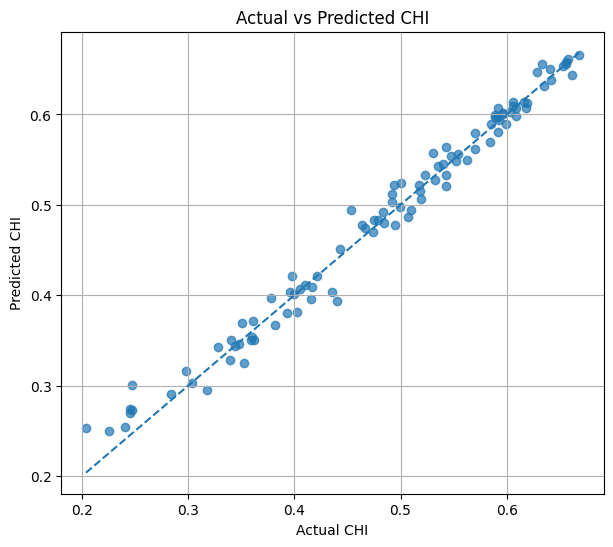

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual CHI")
plt.ylabel("Predicted CHI")
plt.title("Actual vs Predicted CHI")

plt.grid(True)
plt.show()

FEATURE IMPORTANCE
     Feature  Importance
0      LST_n    0.918945
3     AirT_n    0.029765
6  LULC_Heat    0.021240
2     NDBI_n    0.009706
1     NDVI_n    0.009481
4       RH_n    0.006140
5     Wind_n    0.004722


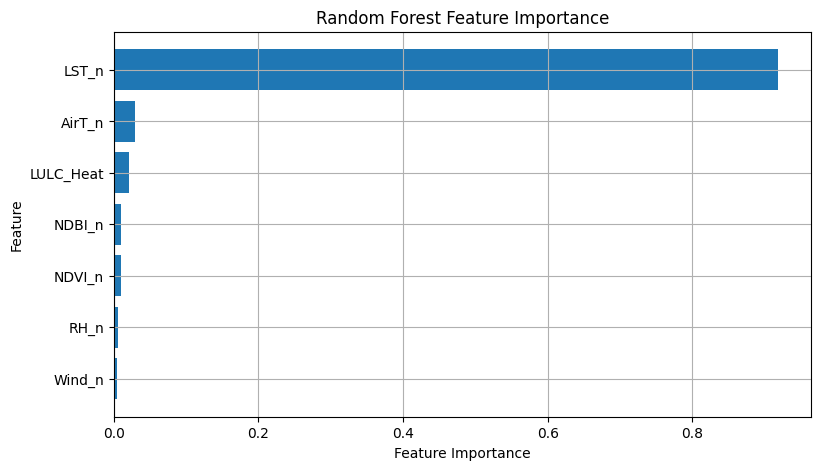

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("=" * 45)
print("FEATURE IMPORTANCE")
print("=" * 45)
print(importance)

plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(True)
plt.show()

In [56]:
import joblib

joblib.dump(model, "rf_chi_model_verified.pkl")
print("Model saved successfully.")

Model saved successfully.


In [57]:
loaded_model = joblib.load("rf_chi_model_verified.pkl")

verified_predictions = loaded_model.predict(X_test)

verified_r2 = r2_score(y_test, verified_predictions)

print("Original R² :", r2)
print("Verified R² :", verified_r2)

Original R² : 0.9820979464593975
Verified R² : 0.9820979464593975
